In [1]:
import pandas as pd
import numpy as np
import holidays as hp
from xgboost import  XGBRegressor
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.regularizers import L2
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import  TimeSeriesSplit
from tensorflow.keras.optimizers import SGD
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.graphics.tsaplots import  plot_acf


2026-08-25 16:47:05.198863: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-25 16:47:05.452343: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-08-25 16:47:07.197394: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
df = pd.read_csv('/home/purushottam/MACHINE LEARNING/TIME SERIES/COMPTETIONS/FAVORITA COMPETITONS/favo store sales.csv')

In [3]:
df.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [4]:
df = df.sample(n= 50000)


In [8]:
def process_data(df):
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values('date')
    
    df_category = df.select_dtypes(include= 'str').columns
    df = pd.get_dummies(df, columns= df_category)

    df = df.drop_duplicates(subset= 'sales')
    
    q1 = df['sales'].quantile(0.25)
    q3 = df['sales'].quantile(0.75)

    iqr = q3 - q1

    upper = q3 + 1.5 * iqr

    lower = q1  - 1.5 * iqr

    df = df[(df['sales'] <= upper) & (df['sales'] >= 10)]

    
    return df



In [10]:
df = process_data(df)



In [11]:
us_holidays = hp.US(years = range(df['date'].dt.year.min() , df['date'].dt.year.max() + 2))

date_holidays = sorted(us_holidays.keys())

def days_to_holidays(date):

    future_holidays = [h for h in date_holidays if h >= date.date()]

    if future_holidays:
        return (future_holidays[0] - date.date()).days

    return None

    

In [12]:
def time(df):
    df['Month'] = df['date'].dt.month
    df['Year'] = df['date'].dt.year
    df['Dayofweek'] = df['date'].dt.dayofweek
    df['Dayofyear'] = df['date'].dt.dayofyear
    df['Day'] = df['date'].dt.day
    df['Quarter'] = df['date'].dt.quarter
    return df

def features_target(df):
    df['Target'] = df['sales'].shift(-1)
    df['Lag 1'] = df['sales'].shift(1)
    df['Lag 7'] = df['sales'].shift(7)
    df['Lag 30'] = df['sales'].shift(30)
    df['MA 7'] = df['sales'].shift(1).rolling(7).mean()
    df['MA 30'] = df['sales'].shift(1).rolling(30).mean()
    df['STD 7'] = df['sales'].shift(1).rolling(7).std()
    df['STD 30'] = df['sales'].shift(1).rolling(30).std()
    return df




In [13]:
train = df[(df['date'] >= '2013-01-01') & (df['date'] < '2016-03-01')]
val = df[(df['date'] >= '2016-03-01') & (df['date'] < '2017-01-01')]
test = df[(df['date'] >= '2017-01-01') & (df['date'] <= '2017-08-15')]

zero_std_cols = train.columns[train.std() == 0]

train = train.drop(columns= zero_std_cols)
val = val.drop(columns = zero_std_cols)
test = test.drop(columns= zero_std_cols)

In [14]:
train = features_target(train)
train = time(train)

val = features_target(val)
val = time(val)

test = features_target(test)
test = time(test)

train['Days_to_holidays'] = train['date'].apply(days_to_holidays)
val['Days_to_holidays'] = val['date'].apply(days_to_holidays)
test['Days_to_holidays'] = test['date'].apply(days_to_holidays)


train.dropna(inplace = True)
val.dropna(inplace= True)
test.dropna(inplace= True)

In [15]:
del train['date']
del val['date']
del test['date']

In [16]:
x_train = train.drop('Target', axis = 1)
y_train = train['Target']

x_val = val.drop('Target', axis = 1)
y_val = val['Target']

x_test = test.drop('Target', axis = 1)
y_test = test['Target']


In [17]:
def Time_Series_validate(x_train, y_train):
    
    tsv = TimeSeriesSplit(n_splits= 5)

    pred = np.full(len(x_train),np.nan)

    for fold,(train_idx, pred_idx) in enumerate(tsv.split(x_train)):
        x_tr = x_train.iloc[train_idx]
        y_tr = y_train.iloc[train_idx]

        predi = x_train.iloc[pred_idx]

        model = XGBRegressor(n_estimators=  1500, learning_rate = 0.005, max_depth = 5, device = 'cuda')

        model.fit(x_tr, y_tr)

        pred[pred_idx] = model.predict(predi)

    return pred


In [92]:
def validate(x_train, y_train, x_val, y_val, retrain_every):
    history_x = x_train.copy()

    history_y = y_train.copy()
    
    model = XGBRegressor(n_estimators = 1000, learning_rate = 0.005, max_depth = 7, device = 'cuda')

    predictions = []
    
    for start in range(0, len(x_val), retrain_every):
        
        
        model.fit(history_x, history_y)

        end = min(start + retrain_every, len(x_val))

        batch_x = x_val.iloc[start:end]

        pred = model.predict(batch_x)

        pred = np.asarray(pred)

        predictions.extend(pred)

        print ('batch:' ,start, 'batch_x:',len(batch_x), 'pred:',len(pred))

        history_x = pd.concat([history_x, x_val.iloc[start:end]])
        history_y = pd.concat([history_y, y_val.iloc[start:end]])
        loss = mean_absolute_error(y_val[start:end], pred)
        print (f'Loss = {loss}')

    error = mean_absolute_error(y_val, predictions)


    residual = y_val - predictions

    return error, predictions, residual

    


In [50]:
time_train_pred = Time_Series_validate(x_train, y_train)

In [93]:
mae_val, pred_val, residuals_val = validate(x_train, y_train, x_val, y_val, 7)

batch: 0 batch_x: 7 pred: 7
Loss = 228.2355656347656
batch: 7 batch_x: 7 pred: 7
Loss = 166.5844699707031
batch: 14 batch_x: 7 pred: 7
Loss = 247.65346943010601
batch: 21 batch_x: 7 pred: 7
Loss = 235.93850240652904
batch: 28 batch_x: 7 pred: 7
Loss = 187.51272506947544
batch: 35 batch_x: 7 pred: 7
Loss = 289.5875991210938
batch: 42 batch_x: 7 pred: 7
Loss = 184.7805416434152
batch: 49 batch_x: 7 pred: 7
Loss = 412.41572216796874
batch: 56 batch_x: 7 pred: 7
Loss = 243.2034263044085
batch: 63 batch_x: 7 pred: 7
Loss = 327.5093019308036
batch: 70 batch_x: 7 pred: 7
Loss = 274.15825020926343
batch: 77 batch_x: 7 pred: 7
Loss = 175.74842061941965
batch: 84 batch_x: 7 pred: 7
Loss = 179.51474538002233
batch: 91 batch_x: 7 pred: 7
Loss = 359.8954746791295
batch: 98 batch_x: 7 pred: 7
Loss = 409.3881704275949
batch: 105 batch_x: 7 pred: 7
Loss = 304.1401735142299
batch: 112 batch_x: 7 pred: 7
Loss = 235.52442253766745
batch: 119 batch_x: 7 pred: 7
Loss = 192.88280879631697
batch: 126 batch_x

In [94]:
print (mae_val)


249.8461131162155


In [95]:
mae_test, pred_test, residual_test = validate(x_train, y_train, x_test, y_test, 7)

batch: 0 batch_x: 7 pred: 7
Loss = 224.64829671805245
batch: 7 batch_x: 7 pred: 7
Loss = 274.12345154743304
batch: 14 batch_x: 7 pred: 7
Loss = 211.727142124721
batch: 21 batch_x: 7 pred: 7
Loss = 238.32251601143975
batch: 28 batch_x: 7 pred: 7
Loss = 90.36720054408481
batch: 35 batch_x: 7 pred: 7
Loss = 264.2334434492188
batch: 42 batch_x: 7 pred: 7
Loss = 156.91408394949775
batch: 49 batch_x: 7 pred: 7
Loss = 302.4036473563057
batch: 56 batch_x: 7 pred: 7
Loss = 228.26142947823658
batch: 63 batch_x: 7 pred: 7
Loss = 149.0223974609375
batch: 70 batch_x: 7 pred: 7
Loss = 171.7983113839286
batch: 77 batch_x: 7 pred: 7
Loss = 109.76688438197546
batch: 84 batch_x: 7 pred: 7
Loss = 172.54532023716516
batch: 91 batch_x: 7 pred: 7
Loss = 208.5494566434152
batch: 98 batch_x: 7 pred: 7
Loss = 311.4983519489397
batch: 105 batch_x: 7 pred: 7
Loss = 377.4983179408482
batch: 112 batch_x: 7 pred: 7
Loss = 185.26756152901785
batch: 119 batch_x: 7 pred: 7
Loss = 257.4726821463449
batch: 126 batch_x: 

In [96]:
print (mae_test)

235.8957865684205


In [40]:
xgb = XGBRegressor(n_estimators = 1000, learning_rate = 0.005, max_depth = 7, device = 'cuda')
xgb.fit(x_train, y_train)


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",'cuda'
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [41]:
pred_train = xgb.predict(x_train)
pred_val_x = xgb.predict(x_val)
pred_test_x = xgb.predict(x_test)

In [97]:
mae_train = mean_absolute_error(y_train, pred_train)
print ("TRAIN ERROR:%.2f"%mae_train)
mae_val = mean_absolute_error(y_val, pred_val_x)
print ("VAL ERROR:%.2f"%mae_val)
mae_test  = mean_absolute_error(y_test, pred_test_x)
print ("TEST ERROR:%.2f"%mae_test)

TRAIN ERROR:185.33
VAL ERROR:237.87
TEST ERROR:227.13


In [98]:
mae_val_w = mean_absolute_error(y_val, pred_val)
print ("VAL ERROR:%.2f"%mae_val_w)
mae_test_w  = mean_absolute_error(y_test, pred_test)
print ("TEST ERROR:%.2f"%mae_test_w)

VAL ERROR:249.85
TEST ERROR:235.90


In [44]:
train_lstm = train.copy()
val_lstm = val.copy()
test_lstm = test.copy()

In [45]:
train_lstm['Target'] = train_lstm['sales'].shift(-1)
val_lstm['Target'] = val_lstm['sales'].shift(-1)
test_lstm['Target'] = test_lstm['sales'].shift(-1)

In [46]:
train_lstm.dropna(inplace= True)
val_lstm.dropna(inplace= True)
test_lstm.dropna(inplace= True)

In [47]:
x_train_lstm = train_lstm.drop('Target', axis = 1)
y_train_lstm = train_lstm['Target']

x_val_lstm = val_lstm.drop('Target', axis = 1)
y_val_lstm = val_lstm['Target']

x_test_lstm = test_lstm.drop('Target', axis = 1)
y_test_lstm = test_lstm['Target']

In [48]:
zero_std_colss = x_train_lstm.columns[x_train_lstm.std() == 0]

x_train_lstm = x_train_lstm.drop(columns= zero_std_colss)

x_val_lstm = x_val_lstm.drop(columns= zero_std_colss)

x_test_lstm = x_test_lstm.drop(columns= zero_std_colss)

In [49]:
def window(x, y, window):
    x = np.array(x)
    y = np.array(y)

    x_seq = []
    y_seq = []

    for i in range(window, len(x)):
        x_seq.append(x[i - window : i])
        y_seq.append(y[i])

    return np.array(x_seq), np.array(y_seq)

In [50]:
x_mean = x_train_lstm.mean()
x_std = x_train_lstm.std()

x_train_sc = (x_train_lstm - x_mean) / x_std
x_val_sc = (x_val_lstm - x_mean) / x_std
x_test_sc = (x_test_lstm - x_mean) / x_std

y_mean = y_train_lstm.mean()
y_std = y_train_lstm.std()

y_train_sc = (y_train_lstm - y_mean) / y_std
y_val_sc = (y_val_lstm - y_mean) / y_std
y_test_sc = (y_test_lstm - y_mean) / y_std



In [51]:
x_train_sc, y_train_sc = window(x_train_sc, y_train_sc, 30)
x_val_sc, y_val_sc = window(x_val_sc, y_val_sc, 30)
x_test_sc, y_test_sc = window(x_test_sc, y_test_sc, 30)


In [52]:
lstm = Sequential()
lstm.add(LSTM(300,  activation= 'relu', input_shape = (x_train_sc.shape[1], x_train_sc.shape[2]),
 kernel_regularizer= L2(0.005), recurrent_regularizer= L2(0.005)))
lstm.add(Dense(256,  activation= 'relu'))
lstm.add(Dense(128,  activation= 'relu'))
lstm.add(Dense(90,  activation= 'relu'))
lstm.add(Dense(64,  activation= 'relu'))
lstm.add(Dropout(0.5))
lstm.add(Dense(32, activation= 'relu'))
lstm.add(Dense(16, activation= 'relu'))
lstm.add(Dense(1))

lstm.compile(optimizer= SGD(learning_rate = 0.009, clipvalue = 0.5, momentum= 0.7), loss= 'mean_absolute_error')



I0000 00:00:1787681152.349695   75931 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3513 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 6GB Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6
/home/purushottam/TIMESERIESGPU/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [55]:
lstm.fit(x_train_sc, y_train_sc, epochs = 350, batch_size= 32)

Epoch 1/350
171/171 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.6163
Epoch 2/350
171/171 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - loss: 0.6215
Epoch 3/350
171/171 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - loss: 0.6121
Epoch 4/350
171/171 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - loss: 0.6205
Epoch 5/350
171/171 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.6108
Epoch 6/350
171/171 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.5979
Epoch 7/350
171/171 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.5949
Epoch 8/350
171/171 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - loss: 0.6032
Epoch 9/350
171/171 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 0.6062
Epoch 10/350
171/171 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.6023
Epoch 11/350
171/171 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.5914
Epoch 12/350
171/171 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.5925
Epoch 13/350
171/171 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.5994
Epoch 14/350
171/171 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.6004
Epoch 15/350
171/171 ━━━━━━━━

In [56]:
predict_train = lstm.predict(x_train_sc)
predict_val = lstm.predict(x_val_sc)
predict_test = lstm.predict(x_test_sc)

171/171 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step
36/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step

2026-08-25 18:37:04.009290: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_229', 8 bytes spill stores, 8 bytes spill loads



40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step
25/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

2026-08-25 18:37:05.615683: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-08-25 18:37:05.615803: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-08-25 18:37:05.615820: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-08-25 18:37:08.347667: I external/l

31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 192ms/step


In [57]:
predict_train = np.reshape(predict_train, (predict_train.shape[0] ,))
predict_val = np.reshape(predict_val, (predict_val.shape[0],))
predict_test = np.reshape(predict_test, (predict_test.shape[0], ))

In [58]:
predict_train = predict_train * y_std.item() + y_mean.item()
predict_val = predict_val * y_std.item() + y_mean.item()
predict_test = predict_test * y_std.item() + y_mean.item()

In [59]:
y_final_train = train['Target'].iloc[8:].to_numpy()
y_final_val = val['Target'].iloc[38:].to_numpy()
y_final_test = test['Target'].iloc[38:].to_numpy()

In [100]:
pred_test = np.asarray(pred_test)
pred_val = np.asarray(pred_val)
pred_test = np.asarray(pred_test)

In [101]:
final_predict_train = (0.6 * pred_train[31:] + 0.4 * predict_train)
final_predict_val = (0.6  * pred_val[31:] + 0.4 * predict_val)
final_predict_test = (0.6 * pred_test[31:] + 0.4 * predict_test)

In [102]:
mae_train_lstm = mean_absolute_error(y_train_lstm.iloc[30:], predict_train)
print ('LSTM TRAIN ERROR:%.2f'%mae_train_lstm)

mae_val_lstm = mean_absolute_error(y_val_lstm.iloc[30:], predict_val)
print ("LSTM VAL ERROR:%.2f"%mae_val_lstm)

mae_test_lstm = mean_absolute_error(y_test_lstm.iloc[30:], predict_test)
print ("LSTM TEST ERROR:%.2f"%mae_test_lstm)

LSTM TRAIN ERROR:62.57
LSTM VAL ERROR:258.25
LSTM TEST ERROR:235.32


In [103]:
mae_final_train = mean_absolute_error(y_final_train[23:], final_predict_train)
print ("TRAIN FINAL ERROR:%.2f"%mae_final_train)

mae_final_val = mean_absolute_error(y_final_val[23:], final_predict_val[30:])
print ("VAL FINAL ERROR:%.2f"%mae_final_val)

mae_final_test = mean_absolute_error(y_final_test[23:], final_predict_test[30:])
print ("TEST FINAL ERROR:%.2f"%mae_final_test)

TRAIN FINAL ERROR:221.37
VAL FINAL ERROR:239.42
TEST FINAL ERROR:225.24


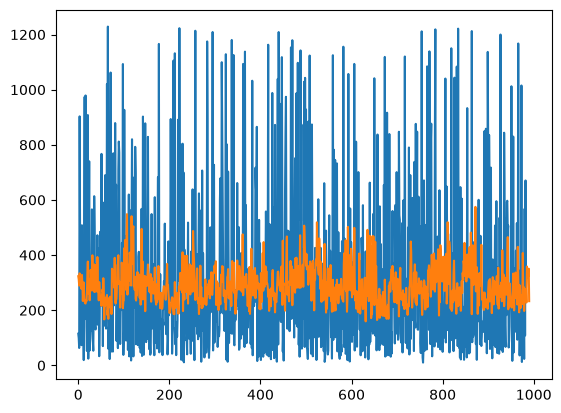

In [104]:
import matplotlib.pyplot as plt

plt.plot(y_final_test)
plt.plot(final_predict_test)

In [83]:
df['Target'] = df['sales'].shift(-1)
df['Persistence'] = df['Target'].shift(1).rolling(7).mean()
df.dropna(inplace= True)
mae_per = mean_absolute_error(df['Target'], df['Persistence'])
print ("PERSISTENCE ERROR:%.2f"%mae_per)

PERSISTENCE ERROR:257.35
